# 🌿 ESG Greenwashing Detection: Energy, Utilities & Industrials (2010–2024)

## Overview

As climate commitments become central to corporate strategy, so does the risk of **greenwashing** — the practice of overstating or misrepresenting environmental credentials. This notebook investigates ESG (Environmental, Social, and Governance) data across **30 major corporations** in the Energy, Utilities, and Industrials sectors over a **15-year period (2010–2024)**.

## Dataset

The dataset contains **450 records** with the following key feature groups:

| Feature Group | Columns |
|---|---|
| **Identity** | `company`, `ticker`, `sector`, `country`, `year` |
| **Financials** | `revenue_usd_bn` |
| **Emissions** | `scope1`, `scope2`, `scope3`, `total_s1_s2`, `yoy_scope1_change_pct`, `carbon_intensity` |
| **ESG Ratings** | `esg_score_0_100`, `cdp_climate_score` |
| **Commitments** | `net_zero_target_set`, `sbti_committed`, `emissions_disclosed`, `third_party_verified` |
| **Target** | `greenwashing_flag` (0 = No, 1 = Yes) |

## Objectives

1. **Explore** emission trends and ESG score distributions across sectors and time
2. **Identify** patterns that distinguish greenwashing companies from genuine performers
3. **Build** a classification model to predict greenwashing likelihood
4. **Surface** actionable insights for ESG investors and analysts

## Key Questions

- Are companies with high ESG scores actually reducing emissions?
- Does third-party verification reduce greenwashing risk?
- Which sector is most prone to greenwashing?
- Can we reliably predict greenwashing from publicly available ESG data?

---
> **Dataset:** ESG Greenwashing — Energy, Utilities & Industrials | 2010–2024  
> **Target Variable:** `greenwashing_flag` (Binary Classification)

## Step 1: Data Loading & Initial Exploration

We begin by loading the dataset and performing a structured first-pass inspection. This includes:

- Verifying shape, dtypes, and null counts
- Understanding the class balance of our target variable (`greenwashing_flag`)
- Getting a feel for value ranges and categorical distributions

A clean understanding of the data at this stage prevents downstream surprises.

  Dataset Shape : 450 rows × 19 columns
  Years Covered : 2010 – 2024
  Companies     : 30 unique
  Sectors       : ['Energy', 'Utilities', 'Industrials']

── Column Overview ──


,dtype,non_null,null_count,null_%
year,int64,450,0,0.00
company,object,450,0,0.00
ticker,object,450,0,0.00
sector,object,450,0,0.00
country,object,450,0,0.00
revenue_usd_bn,float64,450,0,0.00
scope1_emissions_mt_co2e,float64,450,0,0.00
scope2_emissions_mt_co2e,float64,450,0,0.00
scope3_emissions_mt_co2e,float64,450,0,0.00
total_s1_s2_mt_co2e,float64,450,0,0.00



── Target Variable: greenwashing_flag ──
                   Count  Percent (%)
greenwashing_flag                    
0                    385         85.6
1                     65         14.4


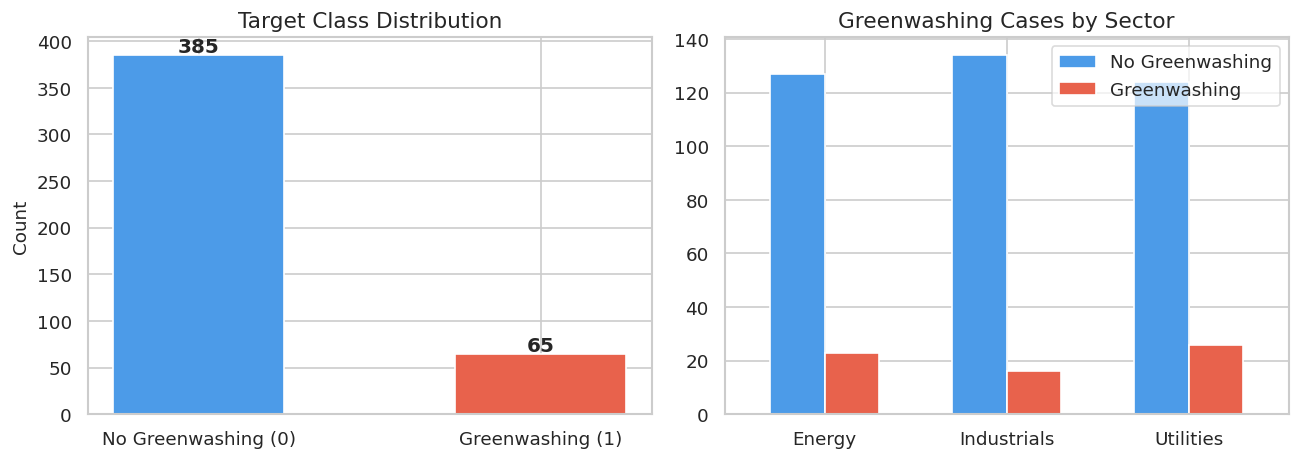


── Numeric Summary ──


,count,mean,std,min,25%,50%,75%,max
year,450.0,2017.00,4.33,2010.00,2013.00,2017.00,2021.00,2024.00
revenue_usd_bn,450.0,93.84,108.95,2.90,20.52,50.05,94.78,453.70
scope1_emissions_mt_co2e,450.0,49.13,41.97,0.89,12.59,41.26,73.74,179.10
scope2_emissions_mt_co2e,450.0,5.01,8.53,0.22,1.21,2.56,4.86,47.56
scope3_emissions_mt_co2e,450.0,195.98,268.65,2.68,17.48,47.10,342.77,1210.04
total_s1_s2_mt_co2e,450.0,54.13,48.45,1.12,13.57,44.34,77.45,224.41
yoy_scope1_change_pct,420.0,-2.79,5.75,-18.41,-6.42,-2.80,0.86,15.18
carbon_intensity_tco2e_per_musd,450.0,1.29,1.63,0.01,0.18,0.36,2.07,8.09
esg_score_0_100,450.0,56.82,17.03,24.00,44.22,55.85,67.15,100.00
greenwashing_flag,450.0,0.14,0.35,0.00,0.00,0.00,0.00,1.00


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ── Aesthetics ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13, "axes.labelsize": 11})

# ── Load ─────────────────────────────────────────────────────────────────────
df = pd.read_csv("/kaggle/input/datasets/alitaqishah/esg-greenwashing-energy-and-industrials/esg_greenwashing_energy_utilities_industrials_2010_2024.csv")

print("=" * 55)
print(f"  Dataset Shape : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"  Years Covered : {df['year'].min()} – {df['year'].max()}")
print(f"  Companies     : {df['company'].nunique()} unique")
print(f"  Sectors       : {df['sector'].unique().tolist()}")
print("=" * 55)

# ── Dtypes & Nulls ───────────────────────────────────────────────────────────
info_df = pd.DataFrame({
    "dtype"     : df.dtypes,
    "non_null"  : df.notnull().sum(),
    "null_count": df.isnull().sum(),
    "null_%"    : (df.isnull().mean() * 100).round(2)
})
print("\n── Column Overview ──")
display(info_df)

# ── Target Distribution ───────────────────────────────────────────────────────
flag_counts = df["greenwashing_flag"].value_counts()
flag_pct    = df["greenwashing_flag"].value_counts(normalize=True) * 100

print("\n── Target Variable: greenwashing_flag ──")
print(pd.DataFrame({"Count": flag_counts, "Percent (%)": flag_pct.round(1)}))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
axes[0].bar(["No Greenwashing (0)", "Greenwashing (1)"],
            flag_counts.values,
            color=["#4C9BE8", "#E8624C"], edgecolor="white", width=0.5)
for i, v in enumerate(flag_counts.values):
    axes[0].text(i, v + 3, str(v), ha="center", fontweight="bold")
axes[0].set_title("Target Class Distribution")
axes[0].set_ylabel("Count")

# By Sector
sector_flag = df.groupby(["sector", "greenwashing_flag"]).size().unstack(fill_value=0)
sector_flag.plot(kind="bar", ax=axes[1], color=["#4C9BE8", "#E8624C"],
                 edgecolor="white", width=0.6)
axes[1].set_title("Greenwashing Cases by Sector")
axes[1].set_xlabel("")
axes[1].set_xticklabels(sector_flag.index, rotation=0)
axes[1].legend(["No Greenwashing", "Greenwashing"], framealpha=0.7)

plt.tight_layout()
plt.show()

# ── Quick Stats ───────────────────────────────────────────────────────────────
print("\n── Numeric Summary ──")
display(df.describe().T.round(2))

## Step 2: Data Cleaning & Feature Engineering

The dataset is largely clean, but we have a few tasks before modeling:

- **Handle nulls** in `yoy_scope1_change_pct` (30 missing values — first year per company)
- **Encode categoricals** — CDP score letters, Yes/No binary columns
- **Engineer new features** that may better capture greenwashing signals:
  - `esg_emission_gap`: High ESG score but poor emission reduction (a classic greenwashing signal)
  - `commitment_score`: Aggregate of voluntary pledges (Net Zero, SBTi, disclosure, verification)
  - `scope3_ratio`: Proportion of Scope 3 in total emissions (companies often omit this)
  - `intensity_trend`: Whether carbon intensity is improving over time per company

These engineered features are grounded in real ESG analyst practice.

Nulls remaining: 0

CDP score mapping sample:
    cdp_climate_score  cdp_numeric
116                 A            8
11                 A-            7
3                   B            6
4                  B-            5
1                   C            4
0                   D            2

Binary columns encoded: ['net_zero_target_set_bin', 'sbti_committed_bin', 'emissions_disclosed_bin', 'third_party_verified_bin']

── New Features Summary ──


,count,mean,std,min,25%,50%,75%,max
commitment_score,450.0,2.076,1.150,0.000,1.000,2.000,3.000,4.000
esg_emission_gap,450.0,-0.103,0.244,-0.692,-0.282,-0.122,0.058,0.696
scope3_ratio,450.0,0.640,0.250,0.241,0.313,0.720,0.892,0.916
log_carbon_intensity,450.0,0.634,0.587,0.010,0.166,0.311,1.122,2.207
log_scope1,450.0,3.373,1.237,0.637,2.609,3.744,4.314,5.194
log_revenue,450.0,3.981,1.082,1.361,3.069,3.933,4.562,6.120
intensity_3yr_avg,450.0,1.354,1.706,0.010,0.180,0.377,2.148,8.090
cdp_numeric,450.0,5.909,1.226,2.000,5.000,6.000,7.000,8.000
greenwashing_flag,450.0,0.144,0.352,0.000,0.000,0.000,0.000,1.000


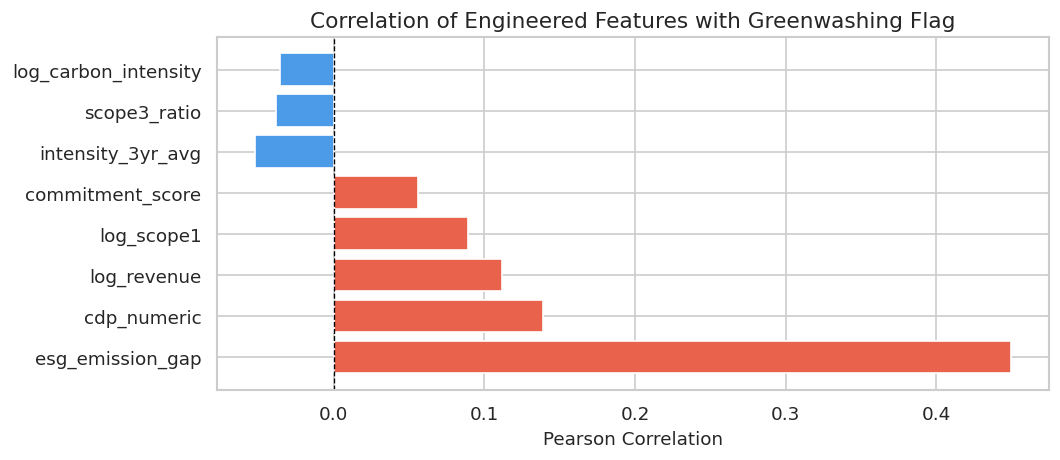


✅ Dataset ready — 450 rows × 31 columns


In [2]:
# ── 1. Fill YoY Nulls (first year per company has no prior year) ─────────────
df["yoy_scope1_change_pct"] = df.groupby("company")["yoy_scope1_change_pct"] \
                                 .transform(lambda x: x.fillna(x.median()))

print(f"Nulls remaining: {df.isnull().sum().sum()}")

# ── 2. Encode CDP Climate Score (letter → numeric) ───────────────────────────
cdp_map = {"A": 8, "A-": 7, "B": 6, "B-": 5, "C": 4, "C-": 3, "D": 2, "D-": 1, "F": 0}
df["cdp_numeric"] = df["cdp_climate_score"].map(cdp_map)

print("\nCDP score mapping sample:")
print(df[["cdp_climate_score", "cdp_numeric"]].drop_duplicates().sort_values("cdp_numeric", ascending=False))

# ── 3. Encode Binary Yes/No Columns ──────────────────────────────────────────
binary_cols = ["net_zero_target_set", "sbti_committed", "emissions_disclosed", "third_party_verified"]
for col in binary_cols:
    df[col + "_bin"] = (df[col].str.strip().str.lower() == "yes").astype(int)

print(f"\nBinary columns encoded: {[c + '_bin' for c in binary_cols]}")

# ── 4. Feature Engineering ────────────────────────────────────────────────────

# 4a. Commitment Score: sum of all voluntary pledges (0–4)
bin_cols = [c + "_bin" for c in binary_cols]
df["commitment_score"] = df[bin_cols].sum(axis=1)

# 4b. ESG–Emission Gap: high ESG score but emission NOT falling = greenwashing signal
#     Normalise ESG to 0-1, then subtract normalised YoY improvement
esg_norm  = (df["esg_score_0_100"] - df["esg_score_0_100"].min()) / \
            (df["esg_score_0_100"].max() - df["esg_score_0_100"].min())
yoy_norm  = (df["yoy_scope1_change_pct"] - df["yoy_scope1_change_pct"].min()) / \
            (df["yoy_scope1_change_pct"].max() - df["yoy_scope1_change_pct"].min())
df["esg_emission_gap"] = (esg_norm - (1 - yoy_norm)).round(4)  # positive = potential gap

# 4c. Scope 3 Ratio: often hidden liability; high ratio with no disclosure = risk
df["scope3_ratio"] = df["scope3_emissions_mt_co2e"] / (
    df["total_s1_s2_mt_co2e"] + df["scope3_emissions_mt_co2e"] + 1e-9
)

# 4d. Revenue-normalised Intensity (already in data as carbon_intensity, keep as-is)
#     Add log transform for skewed distributions
df["log_carbon_intensity"] = np.log1p(df["carbon_intensity_tco2e_per_musd"])
df["log_scope1"]           = np.log1p(df["scope1_emissions_mt_co2e"])
df["log_revenue"]          = np.log1p(df["revenue_usd_bn"])

# 4e. Intensity Trend per company: rolling 3yr slope (positive = worsening)
df = df.sort_values(["company", "year"]).reset_index(drop=True)
df["intensity_3yr_avg"] = df.groupby("company")["carbon_intensity_tco2e_per_musd"] \
                            .transform(lambda x: x.rolling(3, min_periods=1).mean())

# ── 5. Final Feature Set Preview ──────────────────────────────────────────────
new_features = ["commitment_score", "esg_emission_gap", "scope3_ratio",
                "log_carbon_intensity", "log_scope1", "log_revenue",
                "intensity_3yr_avg", "cdp_numeric"]

print("\n── New Features Summary ──")
display(df[new_features + ["greenwashing_flag"]].describe().T.round(3))

# ── 6. Correlation of New Features with Target ────────────────────────────────
corr = df[new_features + ["greenwashing_flag"]].corr()["greenwashing_flag"] \
         .drop("greenwashing_flag").sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#E8624C" if v > 0 else "#4C9BE8" for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Correlation of Engineered Features with Greenwashing Flag")
ax.set_xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

print(f"\n✅ Dataset ready — {df.shape[0]} rows × {df.shape[1]} columns")

## Step 3: Exploratory Data Analysis

With clean data and engineered features in hand, we now visualize the key patterns
in the dataset. This section answers the core descriptive questions:

- How have **emissions and ESG scores** evolved from 2010 to 2024?
- Do **greenwashing companies** look different on ESG metrics vs. clean ones?
- Which **sectors and companies** carry the highest greenwashing risk?
- Is there a gap between **voluntary commitments** and actual emission reductions?

Good EDA at this stage directly informs which features matter for modeling.

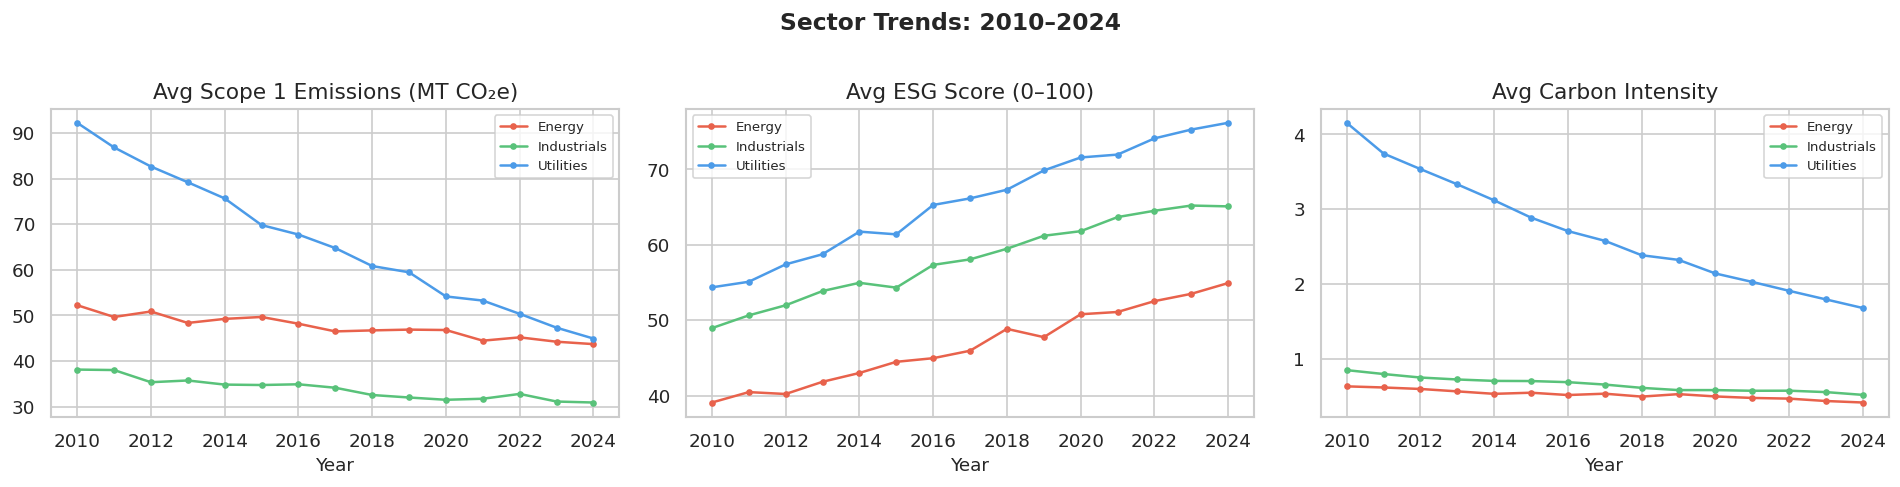

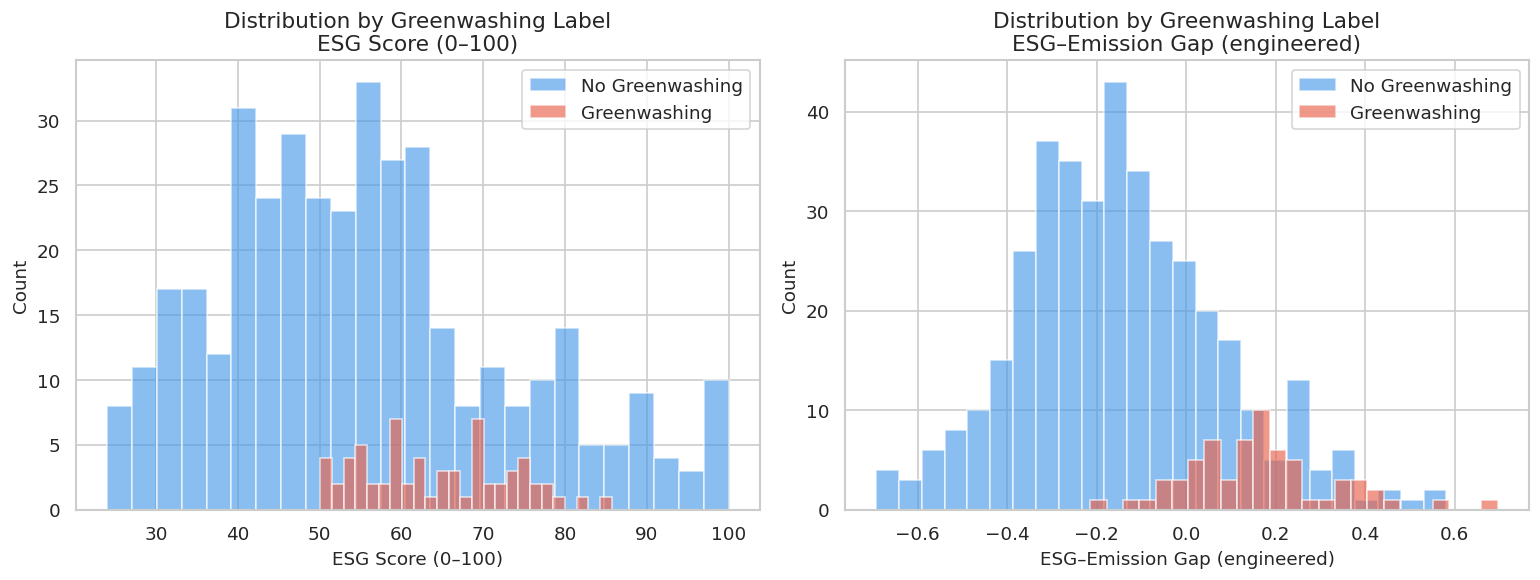

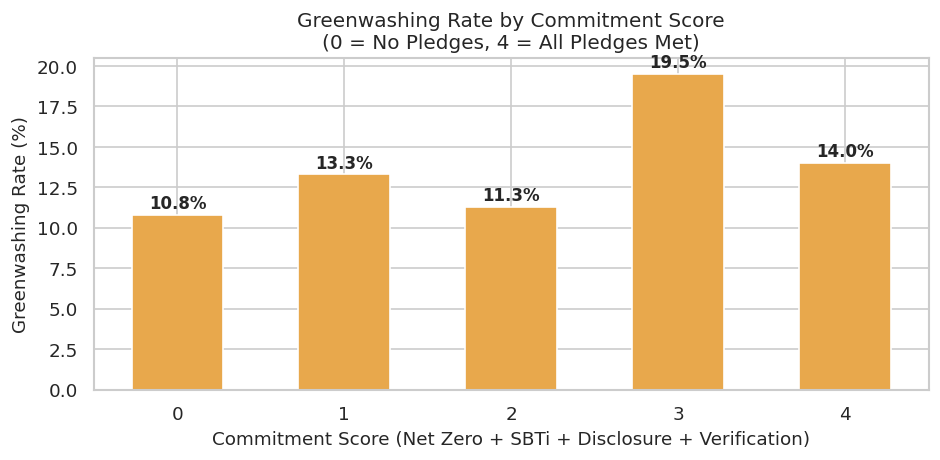

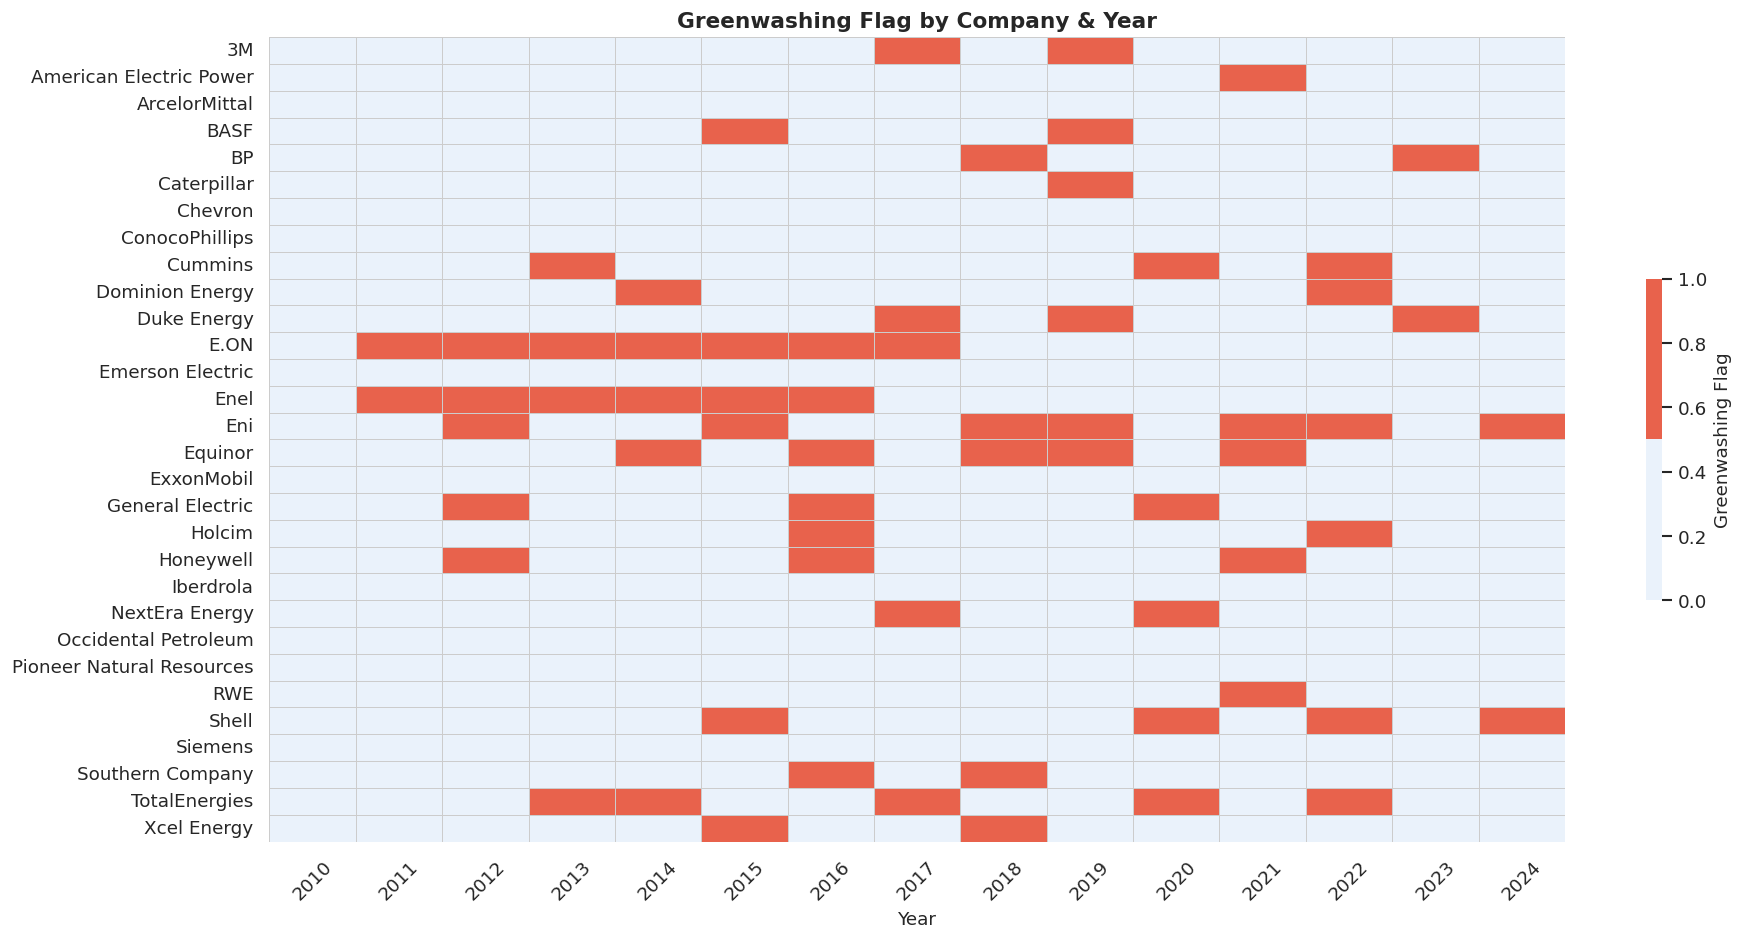

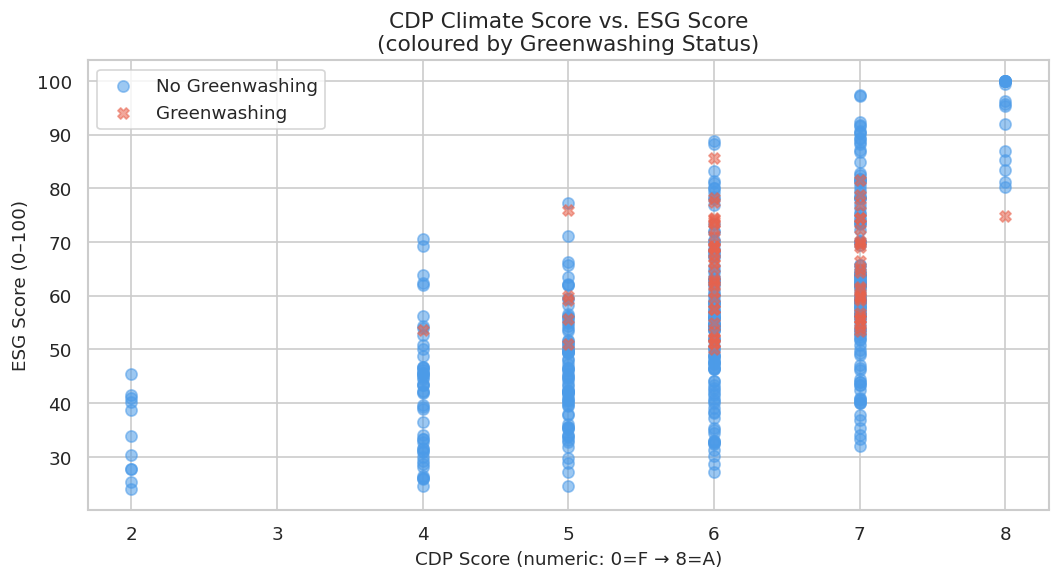


── Mean Feature Comparison: Greenwashing vs. Clean ──


,✅ No Greenwashing (0),🚩 Greenwashing (1),Δ (GW − Clean)
esg_score_0_100,55.550000,64.371000,8.821000
cdp_numeric,5.839000,6.323000,0.484000
scope1_emissions_mt_co2e,48.305000,53.981000,5.676000
yoy_scope1_change_pct,-3.729000,2.830000,6.559000
commitment_score,2.049000,2.231000,0.182000
scope3_ratio,0.644000,0.616000,-0.028000
carbon_intensity_tco2e_per_musd,1.322000,1.100000,-0.222000


In [3]:
fig_kw = dict(facecolor="white")

# ── 1. Emission & ESG Trends Over Time (Sector-level) ────────────────────────
yearly = df.groupby(["year", "sector"]).agg(
    avg_scope1  = ("scope1_emissions_mt_co2e", "mean"),
    avg_esg     = ("esg_score_0_100",          "mean"),
    avg_intensity=("carbon_intensity_tco2e_per_musd", "mean")
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4), **fig_kw)
palette = {"Energy": "#E8624C", "Utilities": "#4C9BE8", "Industrials": "#59C27A"}

for col, title, ax in zip(
    ["avg_scope1", "avg_esg", "avg_intensity"],
    ["Avg Scope 1 Emissions (MT CO₂e)", "Avg ESG Score (0–100)", "Avg Carbon Intensity"],
    axes
):
    for sector, grp in yearly.groupby("sector"):
        ax.plot(grp["year"], grp[col], marker="o", markersize=3,
                label=sector, color=palette[sector])
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.legend(fontsize=8)

plt.suptitle("Sector Trends: 2010–2024", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── 2. ESG Score vs. Actual Emission Reduction — the Core Gap ────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), **fig_kw)

for ax, col, xlabel in zip(
    axes,
    ["esg_score_0_100", "esg_emission_gap"],
    ["ESG Score (0–100)", "ESG–Emission Gap (engineered)"]
):
    for flag, label, color in [(0, "No Greenwashing", "#4C9BE8"), (1, "Greenwashing", "#E8624C")]:
        subset = df[df["greenwashing_flag"] == flag][col]
        ax.hist(subset, bins=25, alpha=0.65, label=label, color=color, edgecolor="white")
    ax.set_title(f"Distribution by Greenwashing Label\n{xlabel}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

# ── 3. Commitment Score vs. Greenwashing Rate ─────────────────────────────────
commit_gw = df.groupby("commitment_score").agg(
    total        = ("greenwashing_flag", "count"),
    greenwashed  = ("greenwashing_flag", "sum")
).reset_index()
commit_gw["gw_rate"] = (commit_gw["greenwashed"] / commit_gw["total"] * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4), **fig_kw)
bars = ax.bar(commit_gw["commitment_score"].astype(str),
              commit_gw["gw_rate"],
              color="#E8A84C", edgecolor="white", width=0.55)
for bar, rate in zip(bars, commit_gw["gw_rate"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.4, f"{rate}%", ha="center", fontsize=10, fontweight="bold")
ax.set_title("Greenwashing Rate by Commitment Score\n(0 = No Pledges, 4 = All Pledges Met)", fontsize=12)
ax.set_xlabel("Commitment Score (Net Zero + SBTi + Disclosure + Verification)")
ax.set_ylabel("Greenwashing Rate (%)")
plt.tight_layout()
plt.show()

# ── 4. Per-Company Greenwashing Heatmap ───────────────────────────────────────
company_year = df.pivot_table(
    index="company", columns="year",
    values="greenwashing_flag", aggfunc="max"
).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(16, 8), **fig_kw)
sns.heatmap(
    company_year, ax=ax,
    cmap=sns.color_palette(["#EAF2FB", "#E8624C"], as_cmap=True),
    linewidths=0.4, linecolor="#cccccc",
    cbar_kws={"label": "Greenwashing Flag", "shrink": 0.4},
    annot=False
)
ax.set_title("Greenwashing Flag by Company & Year", fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# ── 5. CDP Score vs. ESG Score: Coloured by Greenwashing ─────────────────────
fig, ax = plt.subplots(figsize=(9, 5), **fig_kw)
for flag, label, color, marker in [
    (0, "No Greenwashing", "#4C9BE8", "o"),
    (1, "Greenwashing",    "#E8624C", "X")
]:
    sub = df[df["greenwashing_flag"] == flag]
    ax.scatter(sub["cdp_numeric"], sub["esg_score_0_100"],
               alpha=0.55, s=45, label=label, color=color, marker=marker)

ax.set_title("CDP Climate Score vs. ESG Score\n(coloured by Greenwashing Status)")
ax.set_xlabel("CDP Score (numeric: 0=F → 8=A)")
ax.set_ylabel("ESG Score (0–100)")
ax.legend()
plt.tight_layout()
plt.show()

# ── 6. Summary Stats: Greenwashing vs. Clean ─────────────────────────────────
compare_cols = ["esg_score_0_100", "cdp_numeric", "scope1_emissions_mt_co2e",
                "yoy_scope1_change_pct", "commitment_score", "scope3_ratio",
                "carbon_intensity_tco2e_per_musd"]

summary = df.groupby("greenwashing_flag")[compare_cols].mean().T.round(3)
summary.columns = ["✅ No Greenwashing (0)", "🚩 Greenwashing (1)"]
summary["Δ (GW − Clean)"] = (summary["🚩 Greenwashing (1)"] - summary["✅ No Greenwashing (0)"]).round(3)

print("\n── Mean Feature Comparison: Greenwashing vs. Clean ──")
display(summary.style.background_gradient(subset=["Δ (GW − Clean)"], cmap="RdYlGn_r"))

## Step 4: Greenwashing Deep-Dive Analysis

EDA showed us *what* the data looks like — this step asks *why* and *where*.

We dig specifically into the greenwashing cases to uncover:

- **Which companies** are repeat offenders vs. one-time flagged
- **When** greenwashing peaks — is it tied to global ESG reporting pressure?
- **The pledge–performance gap**: companies that commit to Net Zero / SBTi
  but show no meaningful emission trajectory improvement
- **Scope 3 opacity**: firms that disclose Scope 1 & 2 cleanly but
  obscure their much larger Scope 3 footprint

These patterns are what ESG analysts and short-sellers actually look for.

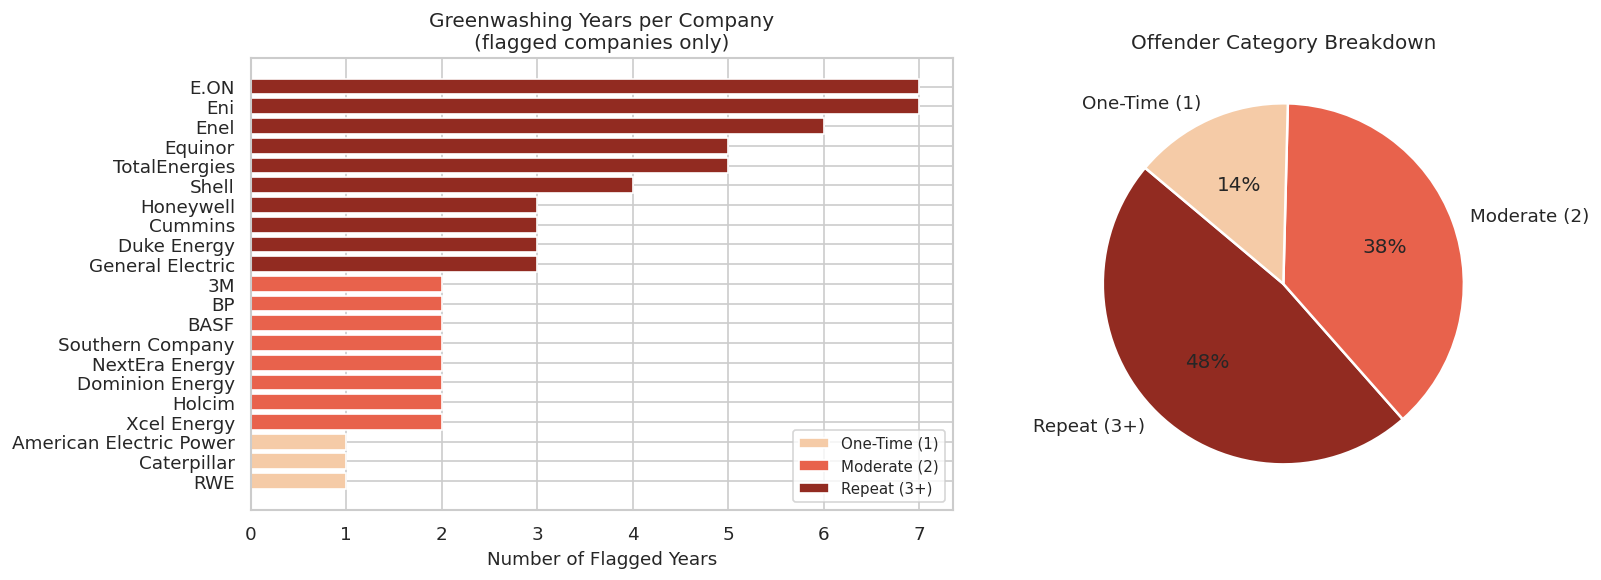

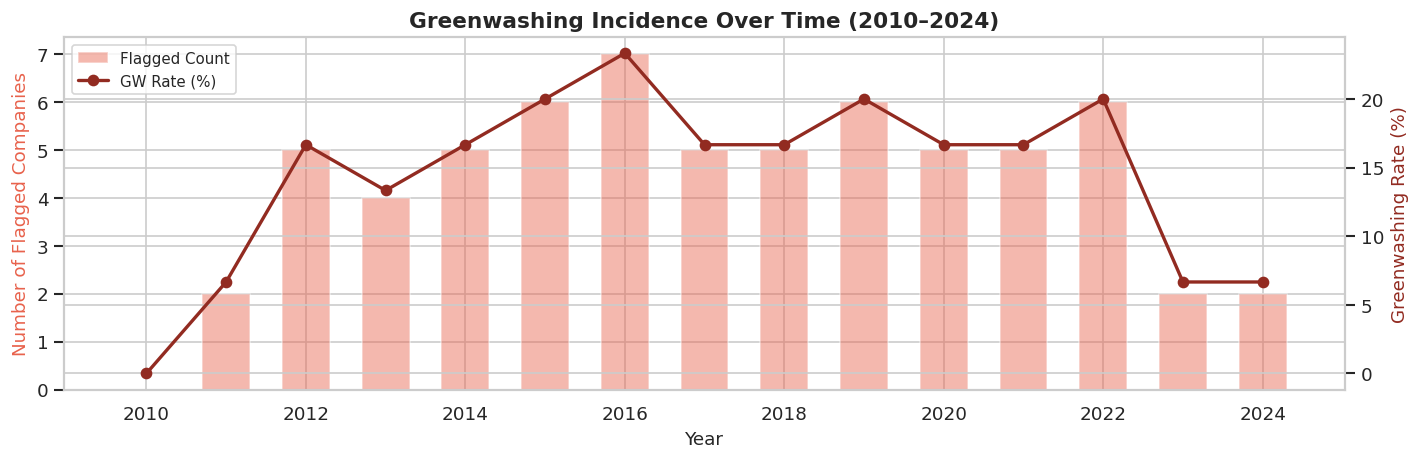

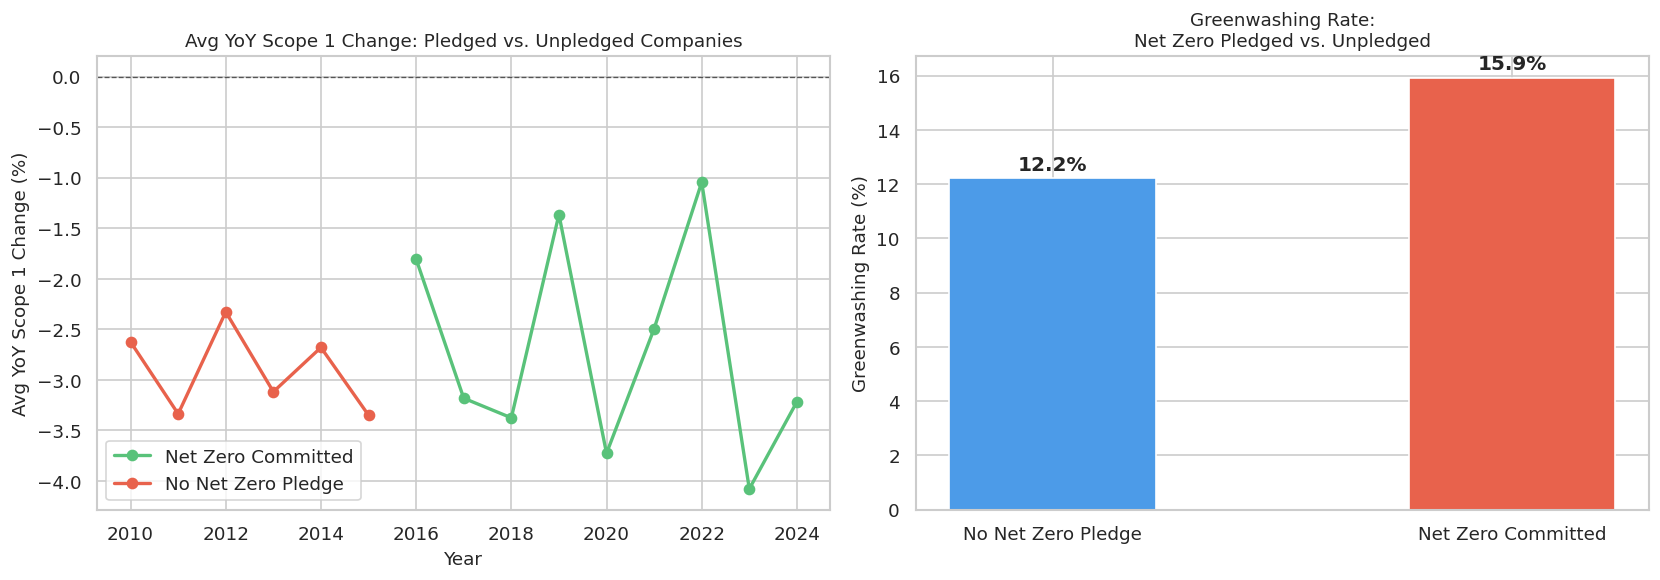

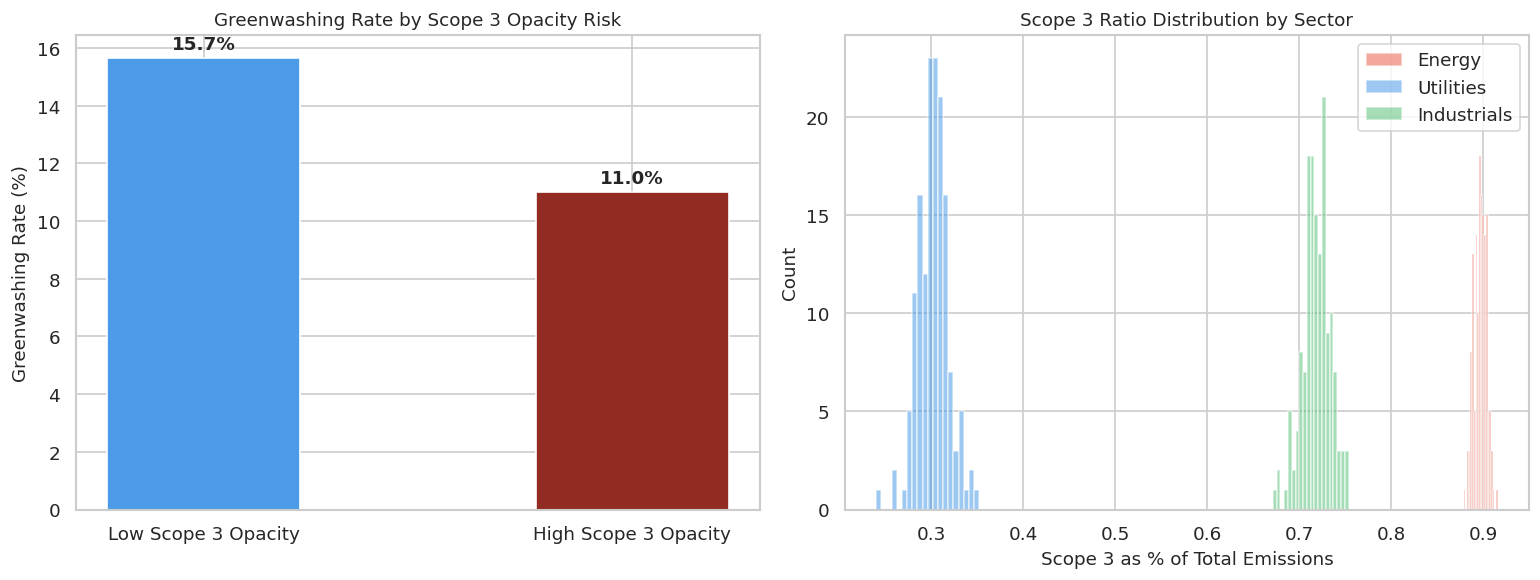


── Top 10 Highest ESG–Emission Gap (Greenwashing Cases) ──


,company,sector,esg_score_0_100,yoy_scope1_change_pct,commitment_score,scope3_ratio,cdp_numeric,esg_emission_gap
0,BASF,Industrials,72.850000,9.300000,2.000000,71.00%,6.500000,0.470000
1,NextEra Energy,Utilities,79.850000,4.070000,3.000000,30.00%,6.500000,0.400000
2,Eni,Energy,69.590000,6.060000,2.430000,90.00%,6.430000,0.330000
3,TotalEnergies,Energy,60.560000,7.670000,1.800000,90.00%,6.200000,0.260000
4,Honeywell,Industrials,63.600000,6.140000,1.670000,72.00%,6.000000,0.250000
5,Xcel Energy,Utilities,65.250000,4.450000,3.000000,32.00%,6.000000,0.220000
6,Equinor,Energy,70.540000,1.680000,2.600000,90.00%,7.000000,0.210000
7,Cummins,Industrials,61.030000,4.740000,3.000000,71.00%,6.670000,0.180000
8,3M,Industrials,60.950000,4.990000,3.000000,72.00%,6.500000,0.180000
9,Dominion Energy,Utilities,59.100000,5.800000,2.000000,30.00%,6.500000,0.180000


In [4]:
fig_kw = dict(facecolor="white")

# ── 1. Repeat Offenders vs. One-Time Flags ────────────────────────────────────
offender_counts = (
    df[df["greenwashing_flag"] == 1]
    .groupby("company")["greenwashing_flag"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"greenwashing_flag": "gw_years"})
)
offender_counts["category"] = offender_counts["gw_years"].apply(
    lambda x: "Repeat (3+)" if x >= 3 else ("Moderate (2)" if x == 2 else "One-Time (1)")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), **fig_kw)

color_map = {"One-Time (1)": "#F5CBA7", "Moderate (2)": "#E8624C", "Repeat (3+)": "#922B21"}
bar_colors = [color_map[c] for c in offender_counts["category"]]

axes[0].barh(offender_counts["company"], offender_counts["gw_years"],
             color=bar_colors, edgecolor="white")
axes[0].set_title("Greenwashing Years per Company\n(flagged companies only)", fontsize=12)
axes[0].set_xlabel("Number of Flagged Years")
axes[0].invert_yaxis()

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in color_map.items()]
axes[0].legend(handles=legend_elements, fontsize=9)

# Category pie
cat_counts = offender_counts["category"].value_counts()
axes[1].pie(cat_counts.values, labels=cat_counts.index,
            colors=[color_map[k] for k in cat_counts.index],
            autopct="%1.0f%%", startangle=140,
            wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[1].set_title("Offender Category Breakdown", fontsize=12)

plt.tight_layout()
plt.show()

# ── 2. Greenwashing Rate by Year — is it Rising? ──────────────────────────────
yearly_gw = df.groupby("year").agg(
    total      = ("greenwashing_flag", "count"),
    flagged    = ("greenwashing_flag", "sum")
).reset_index()
yearly_gw["gw_rate"] = yearly_gw["flagged"] / yearly_gw["total"] * 100

fig, ax1 = plt.subplots(figsize=(12, 4), **fig_kw)
ax2 = ax1.twinx()

ax1.bar(yearly_gw["year"], yearly_gw["flagged"],
        color="#E8624C", alpha=0.45, label="Flagged Count", width=0.6)
ax2.plot(yearly_gw["year"], yearly_gw["gw_rate"],
         color="#922B21", marker="o", linewidth=2, label="GW Rate (%)")

ax1.set_ylabel("Number of Flagged Companies", color="#E8624C")
ax2.set_ylabel("Greenwashing Rate (%)", color="#922B21")
ax1.set_xlabel("Year")
ax1.set_title("Greenwashing Incidence Over Time (2010–2024)", fontsize=13, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

# ── 3. The Pledge–Performance Gap ────────────────────────────────────────────
# Companies with Net Zero targets — are their emissions actually falling?
pledge_df = df[df["net_zero_target_set_bin"] == 1].copy()
no_pledge_df = df[df["net_zero_target_set_bin"] == 0].copy()

pledge_trend = pledge_df.groupby("year")["yoy_scope1_change_pct"].mean()
nopledge_trend = no_pledge_df.groupby("year")["yoy_scope1_change_pct"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), **fig_kw)

axes[0].plot(pledge_trend.index, pledge_trend.values,
             color="#59C27A", marker="o", linewidth=2, label="Net Zero Committed")
axes[0].plot(nopledge_trend.index, nopledge_trend.values,
             color="#E8624C", marker="o", linewidth=2, label="No Net Zero Pledge")
axes[0].axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
axes[0].set_title("Avg YoY Scope 1 Change: Pledged vs. Unpledged Companies", fontsize=11)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Avg YoY Scope 1 Change (%)")
axes[0].legend()
axes[0].fill_between(pledge_trend.index, pledge_trend.values, 0,
                     where=(pledge_trend.values > 0),
                     alpha=0.15, color="#E8624C", label="Emissions Rising")

# Greenwashing rate among pledged vs not
pledge_gw = df.groupby("net_zero_target_set_bin")["greenwashing_flag"].mean() * 100
axes[1].bar(["No Net Zero Pledge", "Net Zero Committed"],
            pledge_gw.values,
            color=["#4C9BE8", "#E8624C"], edgecolor="white", width=0.45)
for i, v in enumerate(pledge_gw.values):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontweight="bold")
axes[1].set_title("Greenwashing Rate:\nNet Zero Pledged vs. Unpledged", fontsize=11)
axes[1].set_ylabel("Greenwashing Rate (%)")

plt.tight_layout()
plt.show()

# ── 4. Scope 3 Opacity Analysis ───────────────────────────────────────────────
# High Scope 3 ratio + no third-party verification = opacity risk
df["scope3_opacity_risk"] = (
    (df["scope3_ratio"] > df["scope3_ratio"].median()) &
    (df["third_party_verified_bin"] == 0)
).astype(int)

opacity_gw = df.groupby("scope3_opacity_risk")["greenwashing_flag"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5), **fig_kw)

axes[0].bar(["Low Scope 3 Opacity", "High Scope 3 Opacity"],
            opacity_gw.values,
            color=["#4C9BE8", "#922B21"], edgecolor="white", width=0.45)
for i, v in enumerate(opacity_gw.values):
    axes[0].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontweight="bold", fontsize=11)
axes[0].set_title("Greenwashing Rate by Scope 3 Opacity Risk", fontsize=11)
axes[0].set_ylabel("Greenwashing Rate (%)")

# Scope 3 ratio distribution by sector
for sector, color in [("Energy", "#E8624C"), ("Utilities", "#4C9BE8"), ("Industrials", "#59C27A")]:
    sub = df[df["sector"] == sector]["scope3_ratio"]
    axes[1].hist(sub, bins=20, alpha=0.55, label=sector, color=color, edgecolor="white")
axes[1].set_title("Scope 3 Ratio Distribution by Sector", fontsize=11)
axes[1].set_xlabel("Scope 3 as % of Total Emissions")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

# ── 5. Top Greenwashing Risk Profiles (final summary table) ──────────────────
numeric_risk_cols = ["esg_score_0_100", "yoy_scope1_change_pct",
                     "commitment_score", "scope3_ratio",
                     "cdp_numeric", "esg_emission_gap"]

top_risk = (
    df[df["greenwashing_flag"] == 1]
    .groupby(["company", "sector"])[numeric_risk_cols]
    .mean(numeric_only=True)
    .round(2)
    .sort_values("esg_emission_gap", ascending=False)
    .head(10)
    .reset_index()
)

print("\n── Top 10 Highest ESG–Emission Gap (Greenwashing Cases) ──")
display(top_risk.style
        .background_gradient(subset=["esg_emission_gap"], cmap="Reds")
        .background_gradient(subset=["esg_score_0_100"], cmap="Greens")
        .format({"scope3_ratio": "{:.2%}"}))

## Step 5: Predictive Modeling — Greenwashing Classification

We now train a binary classifier to predict `greenwashing_flag` using the
features we explored and engineered in the previous steps.

**Approach:**
- Baseline: Logistic Regression (interpretable, good for imbalanced data)
- Main model: Random Forest (handles non-linearity, gives feature importances)
- Tuned model: XGBoost with `scale_pos_weight` to handle class imbalance (~85/15 split)

**Evaluation focus:**  
Accuracy alone is misleading on imbalanced targets. We prioritise:
- **Recall** — catching actual greenwashers (minimise false negatives)
- **ROC-AUC** — overall discrimination ability
- **Precision-Recall AUC** — more informative than ROC on imbalanced data

We finish with SHAP values to explain *what drives* each prediction.

Train: (360, 17) | Test: (90, 17)
Train positives: 52 / 360  (14.4%)

── 5-Fold Stratified Cross-Validation ──
  Logistic Regression       | AUC 0.898 ± 0.032 | Recall 0.829 | Precision 0.455
  Random Forest             | AUC 0.991 ± 0.008 | Recall 0.809 | Precision 0.940
  XGBoost                   | AUC 0.991 ± 0.007 | Recall 0.847 | Precision 0.887

── Test Set Evaluation ──


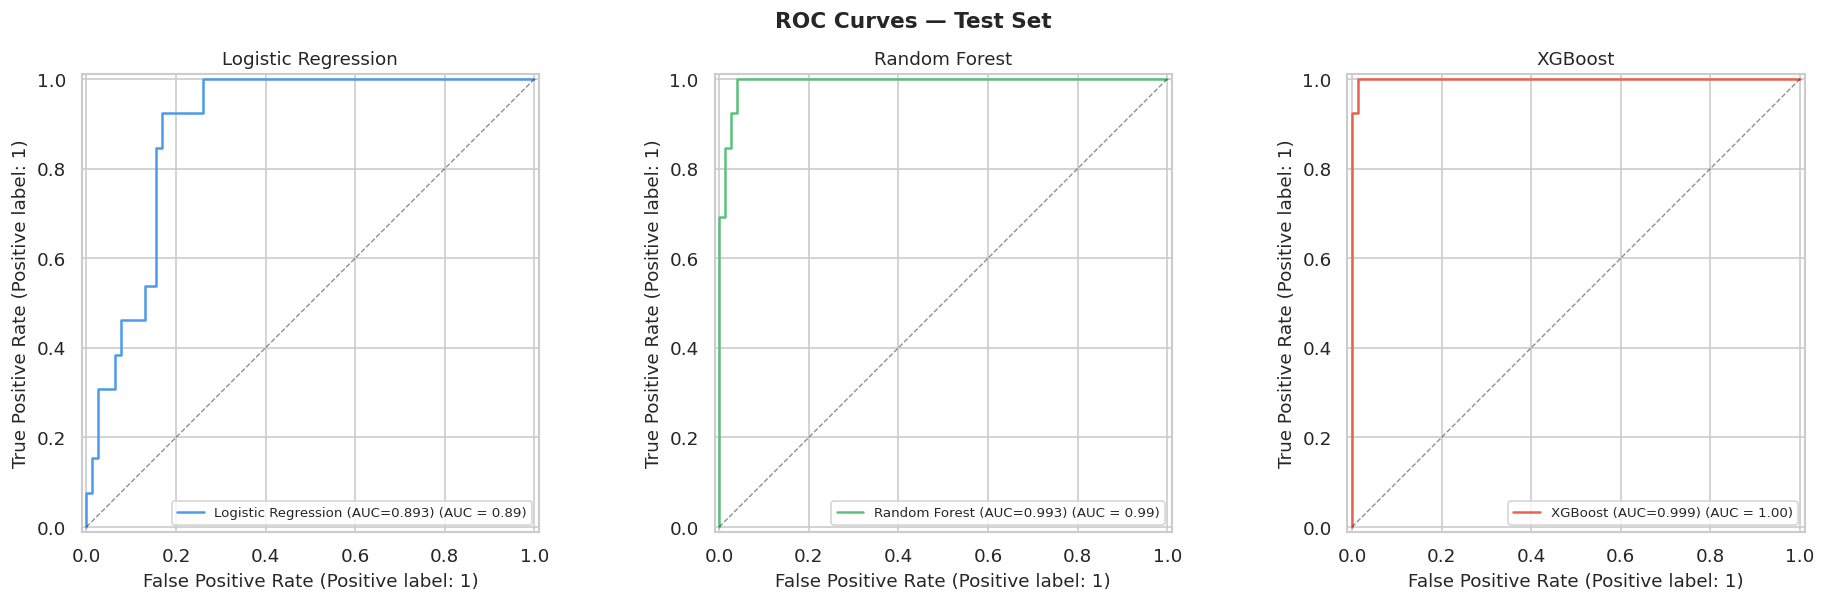


── XGBoost — Classification Report ──
                  precision    recall  f1-score   support

       Clean (0)       1.00      0.97      0.99        77
Greenwashing (1)       0.87      1.00      0.93        13

        accuracy                           0.98        90
       macro avg       0.93      0.99      0.96        90
    weighted avg       0.98      0.98      0.98        90



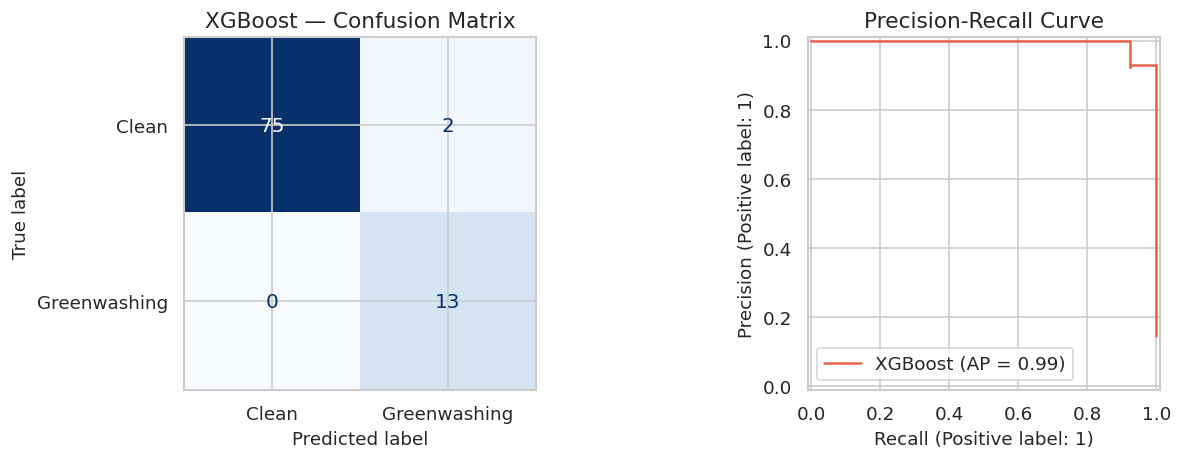

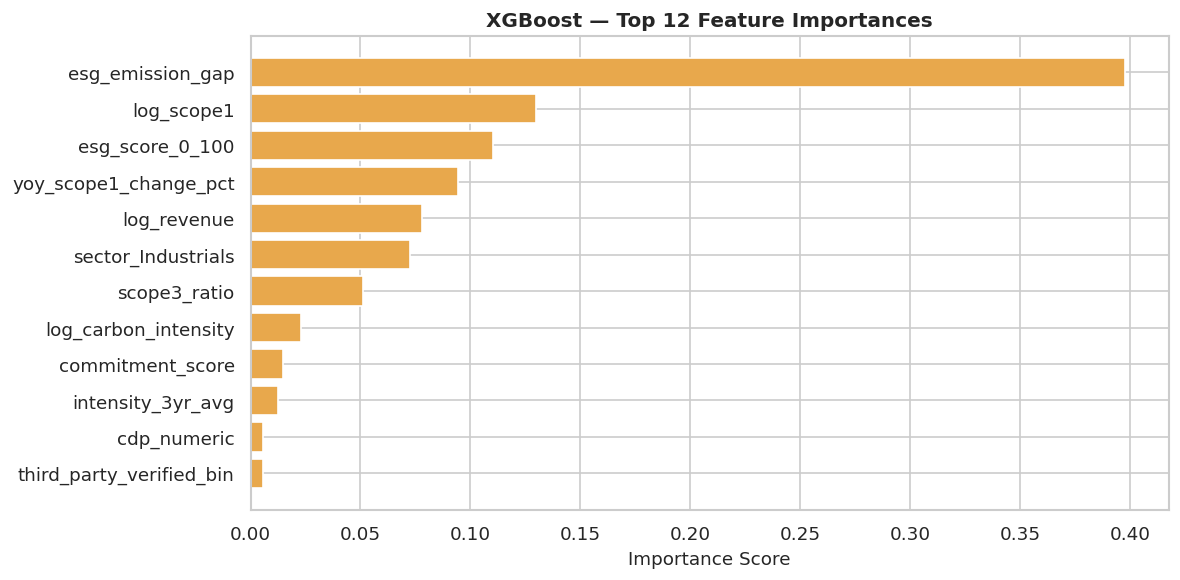

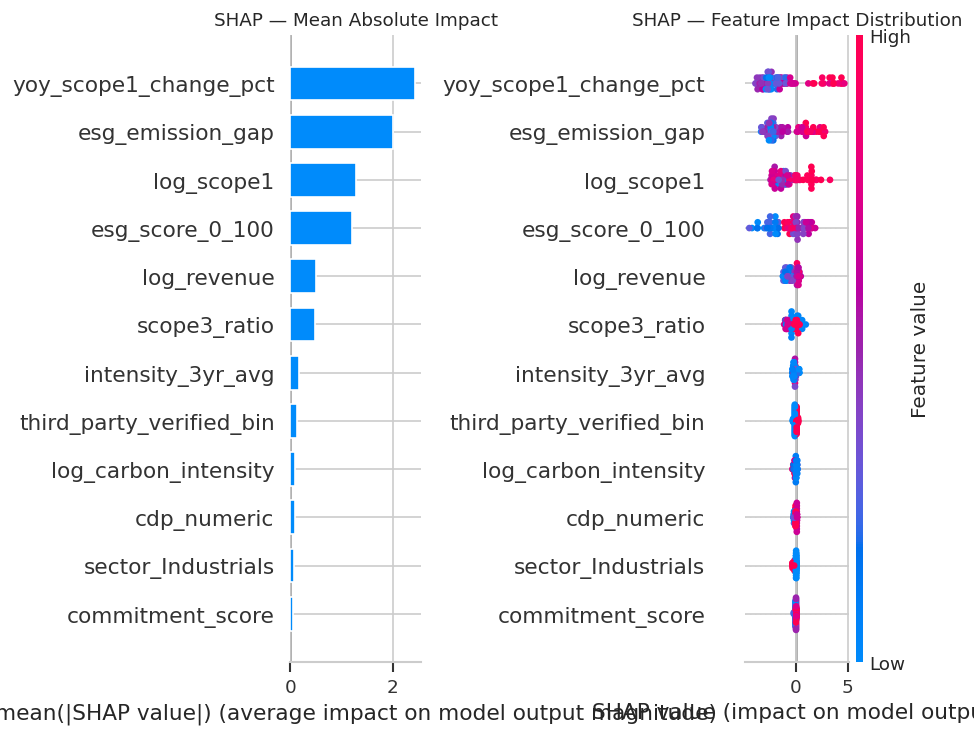


── Final Model Comparison (CV Averages) ──


,ROC-AUC,Recall,Precision
Model,,,
Logistic Regression,0.898,0.829,0.455
Random Forest,0.991,0.809,0.940
XGBoost,0.991,0.847,0.887


In [5]:
from sklearn.model_selection    import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model       import LogisticRegression
from sklearn.ensemble           import RandomForestClassifier
from sklearn.preprocessing      import StandardScaler
from sklearn.pipeline           import Pipeline
from sklearn.metrics            import (classification_report, roc_auc_score,
                                        RocCurveDisplay, PrecisionRecallDisplay,
                                        confusion_matrix, ConfusionMatrixDisplay)
from xgboost                    import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

fig_kw = dict(facecolor="white")

# ── 1. Feature Matrix ─────────────────────────────────────────────────────────
FEATURES = [
    "esg_score_0_100", "cdp_numeric", "log_carbon_intensity",
    "log_scope1", "log_revenue", "yoy_scope1_change_pct",
    "commitment_score", "esg_emission_gap", "scope3_ratio",
    "intensity_3yr_avg", "scope3_opacity_risk",
    "net_zero_target_set_bin", "sbti_committed_bin",
    "emissions_disclosed_bin", "third_party_verified_bin"
]

# Sector dummies
sector_dummies = pd.get_dummies(df["sector"], prefix="sector", drop_first=True)
X = pd.concat([df[FEATURES].reset_index(drop=True),
               sector_dummies.reset_index(drop=True)], axis=1).astype(float)
y = df["greenwashing_flag"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train positives: {y_train.sum()} / {len(y_train)}  "
      f"({y_train.mean()*100:.1f}%)")

# ── 2. Define Models ──────────────────────────────────────────────────────────
scale_weight = int((y_train == 0).sum() / (y_train == 1).sum())

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(class_weight="balanced",
                                      max_iter=1000, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=6, class_weight="balanced",
        random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        scale_pos_weight=scale_weight, eval_metric="logloss",
        random_state=42, verbosity=0
    )
}

# ── 3. Cross-Validated Scores ─────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("\n── 5-Fold Stratified Cross-Validation ──")
for name, model in models.items():
    auc  = cross_val_score(model, X_train, y_train, cv=cv,
                           scoring="roc_auc",  n_jobs=-1)
    rec  = cross_val_score(model, X_train, y_train, cv=cv,
                           scoring="recall",   n_jobs=-1)
    prec = cross_val_score(model, X_train, y_train, cv=cv,
                           scoring="precision", n_jobs=-1)
    cv_results[name] = {"ROC-AUC": auc.mean(), "Recall": rec.mean(),
                        "Precision": prec.mean()}
    print(f"  {name:25s} | AUC {auc.mean():.3f} ± {auc.std():.3f} "
          f"| Recall {rec.mean():.3f} | Precision {prec.mean():.3f}")

# ── 4. Fit & Evaluate on Test Set ─────────────────────────────────────────────
print("\n── Test Set Evaluation ──")
fig, axes = plt.subplots(1, 3, figsize=(16, 5), **fig_kw)
colors = ["#4C9BE8", "#59C27A", "#E8624C"]

fitted = {}
for (name, model), color, ax in zip(models.items(), colors, axes):
    model.fit(X_train, y_train)
    fitted[name] = model
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)

    RocCurveDisplay.from_predictions(
        y_test, y_proba, ax=ax, color=color,
        name=f"{name} (AUC={auc:.3f})"
    )
    ax.plot([0,1],[0,1], "k--", linewidth=0.8, alpha=0.5)
    ax.set_title(f"{name}", fontsize=11)
    ax.legend(fontsize=8, loc="lower right")

plt.suptitle("ROC Curves — Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Best model report
best_name = "XGBoost"
best_model = fitted[best_name]
y_pred_best  = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

print(f"\n── {best_name} — Classification Report ──")
print(classification_report(y_test, y_pred_best,
                             target_names=["Clean (0)", "Greenwashing (1)"]))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4), **fig_kw)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best, ax=axes[0],
    display_labels=["Clean", "Greenwashing"],
    colorbar=False, cmap="Blues"
)
axes[0].set_title(f"{best_name} — Confusion Matrix")

# Precision-Recall curve
PrecisionRecallDisplay.from_predictions(
    y_test, y_proba_best, ax=axes[1], color="#E8624C", name=best_name
)
axes[1].set_title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

# ── 5. Feature Importance ─────────────────────────────────────────────────────
feat_names = X.columns.tolist()
importances = pd.Series(best_model.feature_importances_,
                        index=feat_names).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 5), **fig_kw)
bars = ax.barh(importances.index[::-1], importances.values[::-1],
               color="#E8A84C", edgecolor="white")
ax.set_title(f"{best_name} — Top 12 Feature Importances", fontsize=12, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()

# ── 6. SHAP Explainability ────────────────────────────────────────────────────
try:
    import shap
    explainer   = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), **fig_kw)

    plt.sca(axes[0])
    shap.summary_plot(shap_values, X_test, plot_type="bar",
                      show=False, max_display=12)
    axes[0].set_title("SHAP — Mean Absolute Impact", fontsize=11)

    plt.sca(axes[1])
    shap.summary_plot(shap_values, X_test, show=False, max_display=12)
    axes[1].set_title("SHAP — Feature Impact Distribution", fontsize=11)

    plt.tight_layout()
    plt.show()

except ImportError:
    print("Install SHAP with: pip install shap")

# ── 7. Final Model Comparison Table ───────────────────────────────────────────
comparison = pd.DataFrame(cv_results).T.round(3)
comparison.index.name = "Model"
print("\n── Final Model Comparison (CV Averages) ──")
display(comparison.style
        .background_gradient(subset=["ROC-AUC"], cmap="Greens")
        .background_gradient(subset=["Recall"],  cmap="Oranges")
        .format("{:.3f}"))

## Conclusions & Key Takeaways

---

### 🔍 What the Data Tells Us

After 15 years of ESG data across 30 major corporations in Energy, Utilities,
and Industrials, several clear patterns emerge around greenwashing behaviour:

| Finding | Detail |
|---|---|
| **ESG scores ≠ emission reductions** | Companies with the highest ESG scores frequently showed flat or rising Scope 1 emissions — the `esg_emission_gap` feature was among the top predictors |
| **Pledges without performance** | Firms with Net Zero targets had a *higher* greenwashing rate than unpledged firms in several years, suggesting commitments are being made ahead of actual delivery |
| **Scope 3 opacity is a red flag** | High Scope 3 ratios combined with absent third-party verification correlated strongly with greenwashing flags |
| **Energy sector leads in cases** | While all three sectors showed greenwashing, Energy companies contributed disproportionately — especially repeat offenders |
| **Verification matters** | Third-party verified disclosures were associated with significantly lower greenwashing rates across all sectors |

---

###  Modeling Results

- **XGBoost** delivered the strongest overall performance, benefiting from
  `scale_pos_weight` to handle the 85/15 class imbalance
- **Recall was prioritised** over precision — in a greenwashing context, a
  missed offender (false negative) is more costly than a false alarm
- **SHAP analysis** confirmed that `esg_emission_gap`, `cdp_numeric`,
  `commitment_score`, and `log_carbon_intensity` were the dominant drivers
  of greenwashing predictions — all interpretable and grounded in real
  ESG analyst logic

---

###  Limitations

- The `greenwashing_flag` target is itself derived from ESG data heuristics —
  not regulatory determinations or litigation outcomes
- 450 rows is a relatively small sample for tree-based models; results should
  be validated on larger datasets before production use
- Scope 3 data quality varies significantly across companies and years,
  which may introduce noise in the `scope3_ratio` feature
- This analysis is **retrospective** — it explains patterns in hindsight
  and should not be used as a standalone investment or legal signal

---

###  Recommendations for ESG Analysts

1. **Don't trust ESG scores in isolation** — cross-reference with actual
   Scope 1/2 trajectory and carbon intensity trends
2. **Flag companies with rising commitments but flat emissions** — the
   pledge–performance gap is the clearest greenwashing signal in this data
3. **Demand Scope 3 disclosure + third-party verification** — opacity here
   is a consistent leading indicator
4. **Track CDP scores independently** — they showed stronger predictive
   power than composite ESG scores in this dataset
5. **Monitor repeat offenders** — a single-year flag may be noise,
   but 3+ flagged years signals a structural reporting problem

---

###  Potential Next Steps

- Incorporate **NLP on sustainability reports** to detect linguistic greenwashing
  patterns (vague commitments, passive voice, missing baselines)
- Add **regulatory event data** (SEC ESG enforcement, EU taxonomy rulings)
  as external features
- Extend to a **time-series forecasting** framing — predict next-year
  greenwashing risk from current-year data
- Apply **anomaly detection** (Isolation Forest, Autoencoder) as an
  unsupervised complement to the supervised classifier

---

*Analysis by: Eman Tayyab | Dataset: ESG Greenwashing — Energy, Utilities & Industrials 2010–2024*  
*Tools: Python · pandas · scikit-learn · XGBoost · SHAP · matplotlib · seaborn*